# 02 – EDA: Student Depression Dataset

Utforskande dataanalys inför modellering. Bygger på det **rensade och kodade** datasetet från
`01_Dataforberedelse.ipynb` (`student_depression_clean.csv`) - saknade värden, smutsig data och
irrelevanta kolumner är redan hanterade där.

Mål: förstå distributionerna och vilka variabler som verkar hänga ihop med `Depression`.

In [1]:
import pandas as pd                # DataFrames - tabellhantering
import numpy as np                 # numeriska beräkningar
import matplotlib.pyplot as plt    # plottbibliotek
import seaborn as sns              # visualisering ovanpå matplotlib

sns.set_theme(style="whitegrid")            # global rutnätsstil
pd.set_option("display.max_columns", None)  # visa alla kolumner i output

## Visuell stil

Sätter en gemensam färgpalett och stil en gång här - alla diagram i resten av notebooken
ärver den automatiskt, så vi slipper styla om varje cell för sig.

In [2]:
# Fast, återanvändbar färgpalett - CVD-validerat (colorblind-säkert) blå/röd-par.
PALETTE = {
    "blue": "#2a78d6",     # serie 1 / ena polen i diverging-skalor
    "red": "#e34948",      # serie 2 / andra polen i diverging-skalor
    "orange": "#eb6834",   # serie 3
    "neutral": "#f0efec",  # mittpunkt i diverging-skalor
    "grid": "#e1e0d9",     # hårfina gridlines
    "ink": "#0b0b0b",      # primär textfärg
    "muted": "#898781",    # sekundär text (oanvänd för axel-siffror, se nedan)
    "surface": "#fcfcfb",  # bakgrund
}

# Sätts EN gång, gäller sedan automatiskt för alla diagram nedan.
plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
    "axes.spines.top": False,     # bort med onödiga ramlinjer
    "axes.spines.right": False,
    "text.color": PALETTE["ink"],
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],   # svart för kontrast
    "ytick.color": PALETTE["ink"],   # svart för kontrast
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlelocation": "left",
    "figure.dpi": 200,   # skarp rendering
    "savefig.dpi": 200,
})

sns.set_palette([PALETTE["blue"], PALETTE["red"], PALETTE["orange"]])

## 1. Ladda in datan

In [3]:
df = pd.read_csv("student_depression_clean.csv")  # det REDAN RENSADE datasetet
print(df.shape)
df.head()  # Gender, Sleep Duration m.fl. är redan siffror - se kodningsnyckeln nedan

(27842, 13)


,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,Visakhapatnam,5.0,8.97,2.0,2,3,1,3.0,1.0,0,1
1,0,24.0,Bangalore,2.0,5.90,5.0,2,2,0,3.0,2.0,1,0
2,1,31.0,Srinagar,3.0,7.03,5.0,1,3,0,9.0,1.0,1,0
3,0,28.0,Varanasi,3.0,5.59,2.0,3,2,1,4.0,5.0,1,1
4,0,25.0,Jaipur,4.0,8.13,3.0,2,2,1,1.0,1.0,0,0


### Kodningsnyckel

Kategoriska variabler kodades om till siffror i `01_Dataforberedelse.ipynb`. Referens för att tolka
värdena i resten av denna notebook (t.ex. i korstabellerna nedan):

| Kolumn | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| `Gender` | Female | Male | | | |
| `Have you ever had suicidal thoughts ?` | No | Yes | | | |
| `Family History of Mental Illness` | No | Yes | | | |
| `Dietary Habits` | | Unhealthy | Moderate | Healthy | |
| `Sleep Duration` | | Less than 5h | 5-6h | 7-8h | More than 8h |

`City` lämnades som text (för hög kardinalitet för enkel kodning i detta steg).

In [4]:
# Datatyp + antal icke-tomma värden per kolumn - snabb koll på saknade värden/fel typer.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27842 entries, 0 to 27841
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27842 non-null  int64  
 1   Age                                    27842 non-null  float64
 2   City                                   27842 non-null  str    
 3   Academic Pressure                      27842 non-null  float64
 4   CGPA                                   27842 non-null  float64
 5   Study Satisfaction                     27842 non-null  float64
 6   Sleep Duration                         27842 non-null  int64  
 7   Dietary Habits                         27842 non-null  int64  
 8   Have you ever had suicidal thoughts ?  27842 non-null  int64  
 9   Work/Study Hours                       27842 non-null  float64
 10  Financial Stress                       27842 non-null  float64
 11  Family Histor

## 2. Saknade värden & extremvärden

In [5]:
missing = df.isnull().sum()
missing[missing > 0]  # bör vara TOM - redan hanterat i 01_Dataforberedelse

Series([], dtype: int64)

In [6]:
# Statistik (medel, std, min/max, kvartiler) för numeriska kolumner - upptäck extremvärden.
df.describe(include="number")

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000
mean,0.557252,25.820667,3.141656,7.656027,2.944149,2.399253,1.904605,0.632821,7.158286,3.140435,0.484161,0.585554
std,0.496720,4.906187,1.381729,1.470880,1.360890,1.126845,0.796905,0.482045,3.707158,1.437076,0.499758,0.492635
min,0.000000,18.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,21.000000,2.000000,6.290000,2.000000,1.000000,1.000000,0.000000,4.000000,2.000000,0.000000,0.000000
50%,1.000000,25.000000,3.000000,7.770000,3.000000,2.000000,2.000000,1.000000,8.000000,3.000000,0.000000,1.000000
75%,1.000000,30.000000,4.000000,8.920000,4.000000,3.000000,3.000000,1.000000,10.000000,4.000000,1.000000,1.000000
max,1.000000,59.000000,5.000000,10.000000,5.000000,4.000000,3.000000,1.000000,12.000000,5.000000,1.000000,1.000000


In [7]:
# Samma sak för TEXT-kolumner: antal unika värden, vanligaste värdet ("top") m.m.
df.describe(include="object")

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_64985/2171794019.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,City
count,27842
unique,30
top,Kalyan
freq,1569


## 3. Kolumner som redan hanterats

`Profession`, `Work Pressure`, `Job Satisfaction`, `Degree` och `id` var mest tomma/irrelevanta
(majoriteten i datasetet är heltidsstudenter) och droppades redan i `01_Dataforberedelse.ipynb`.

## 4. Målvariabeln: balans

In [8]:
# normalize=True ger ANDELAR istället för antal - kollar om målvariabeln är balanserad.
df["Depression"].value_counts(normalize=True)

Depression
1    0.585554
0    0.414446
Name: proportion, dtype: float64

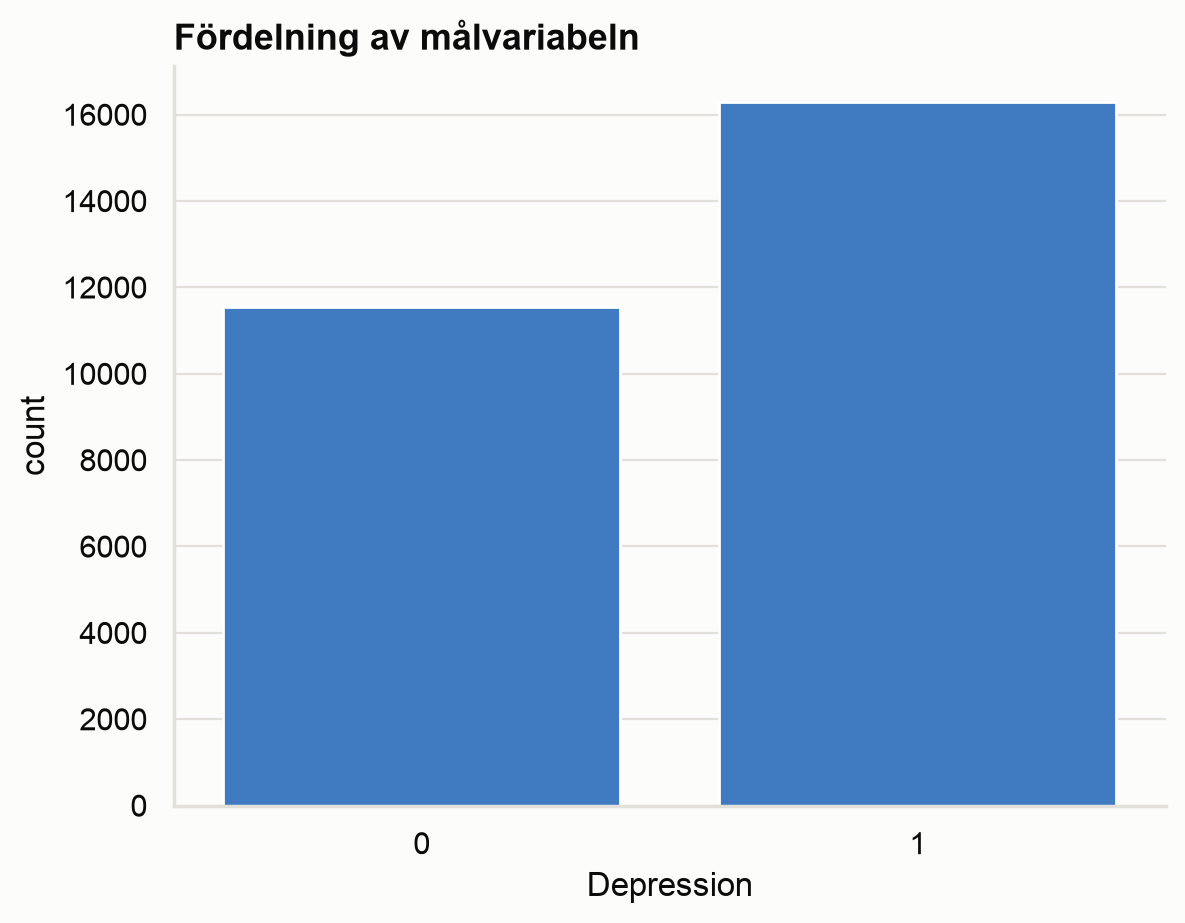

In [9]:
# Samma info som ovan, som stapeldiagram.
sns.countplot(data=df, x="Depression")
plt.title("Fördelning av målvariabeln")
plt.show()

## 5. Korrelationsöversikt

Första konkreta spadtaget: en heatmap över alla numeriska/kodade variabler, för att se
vad som hänger ihop med `Depression` (och med varandra) innan vi djupdyker i enskilda variabler.

**OBS:** korrelation fångar bara *linjära* samband - en låg siffra utesluter inte ett
verkligt mönster (se t.ex. Sleep Duration längre fram). Heatmapen är en kompass för var
vi ska titta närmare, inte facit.

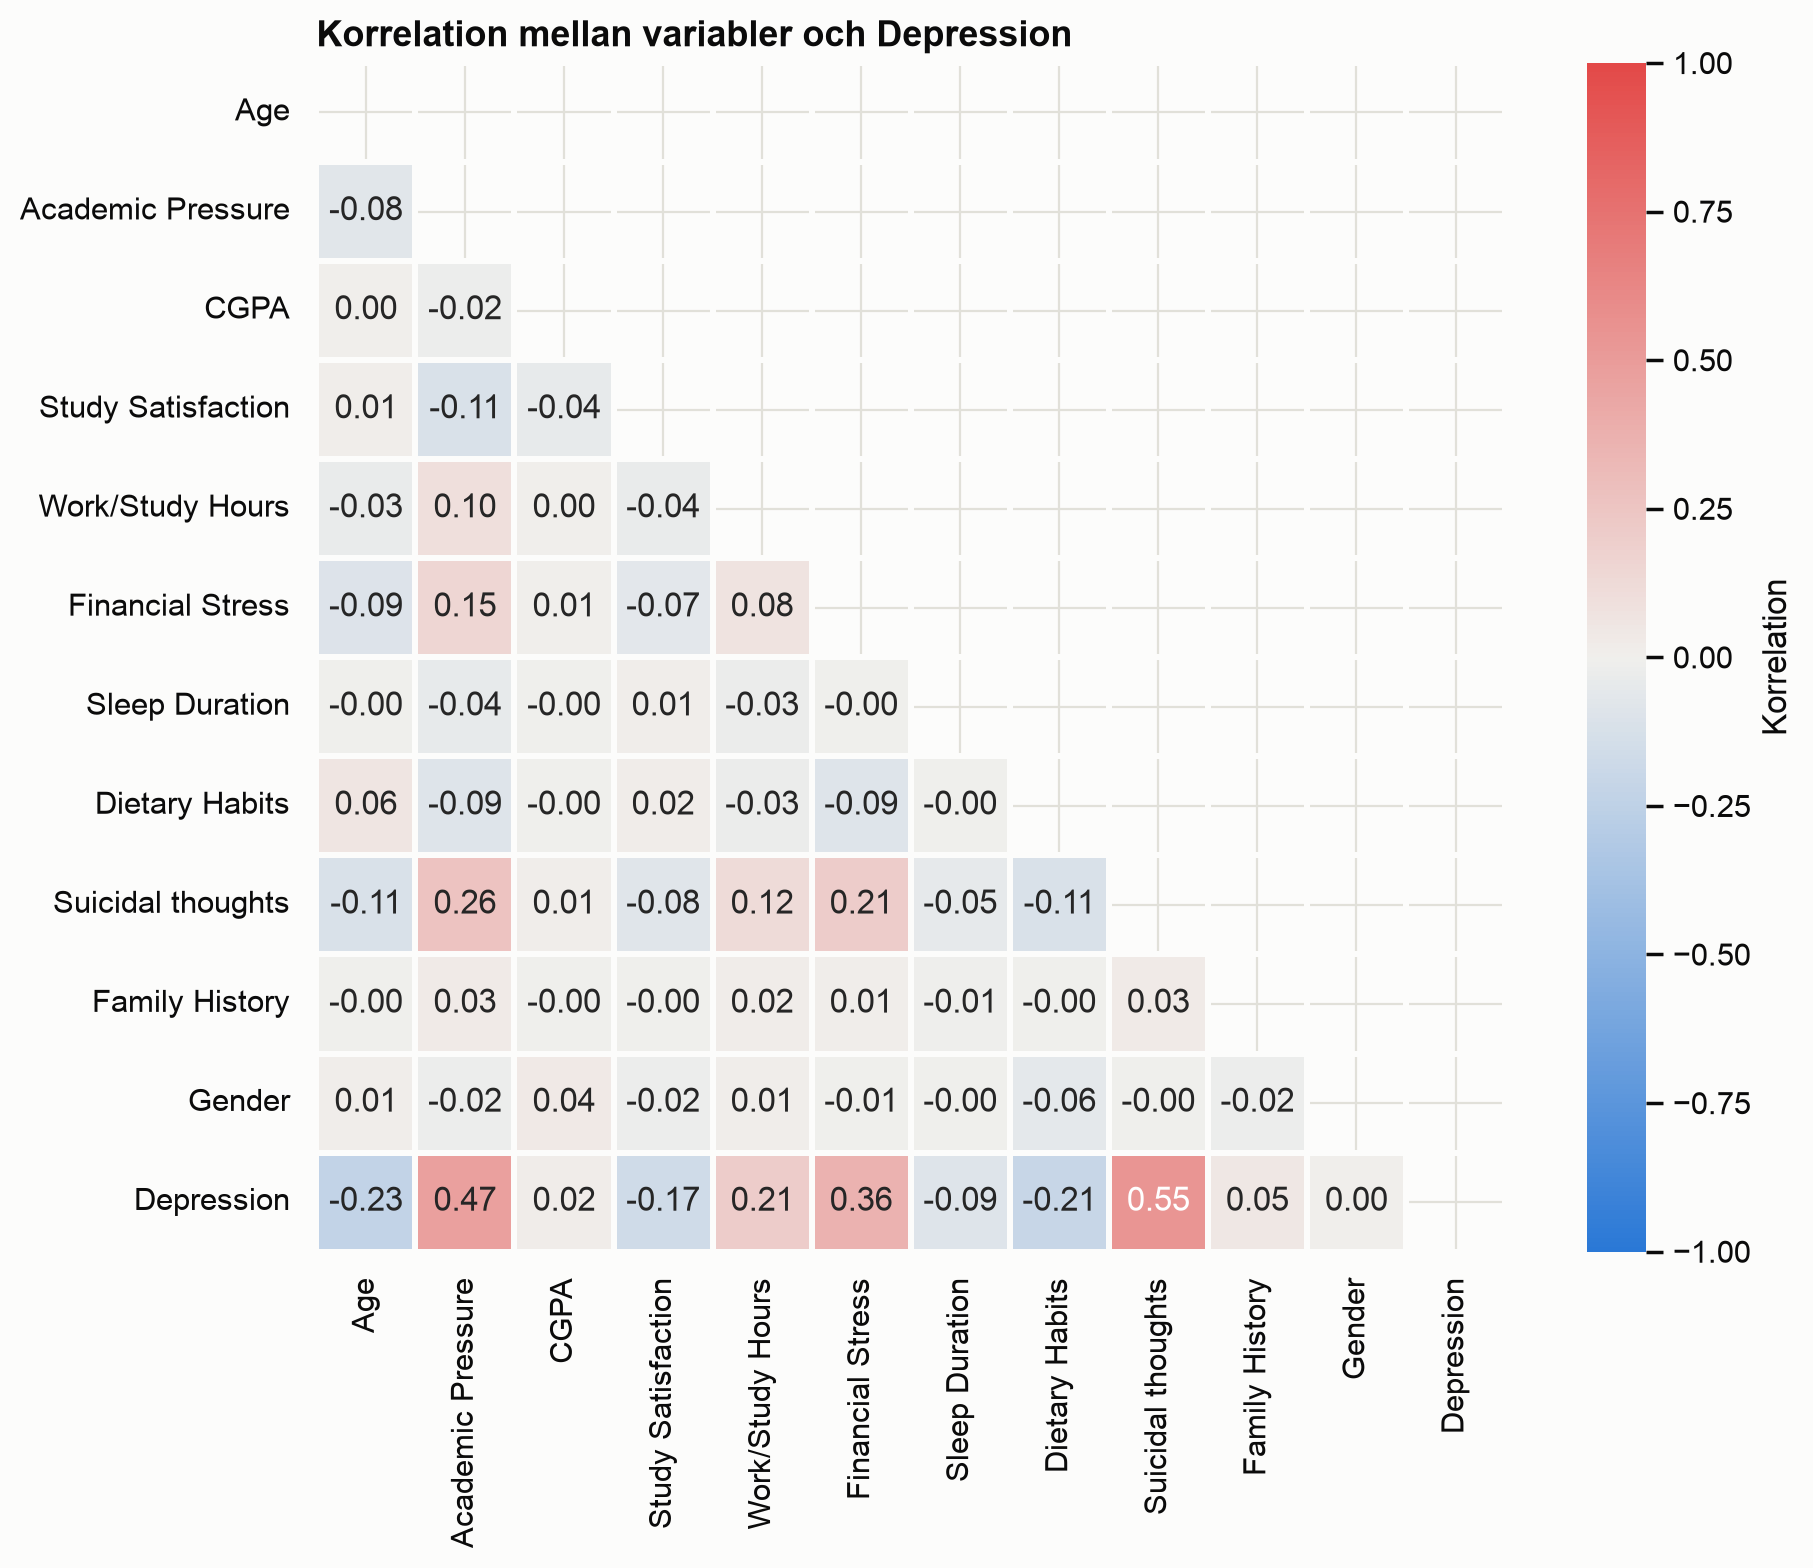

In [10]:
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = [
    "Age", "Academic Pressure", "CGPA", "Study Satisfaction", "Work/Study Hours",
    "Financial Stress", "Sleep Duration", "Dietary Habits",
    "Have you ever had suicidal thoughts ?", "Family History of Mental Illness",
    "Gender",
]
corr = df[numeric_cols + ["Depression"]].corr(numeric_only=True)

# Kortare visningsnamn bara för diagrammet - datan/df:n ändras inte.
short_labels = {
    "Have you ever had suicidal thoughts ?": "Suicidal thoughts",
    "Family History of Mental Illness": "Family History",
}
corr = corr.rename(index=short_labels, columns=short_labels)

# Diverging skala (blå -> neutral -> röd) eftersom 0 är en meningsfull mittpunkt.
brand_diverging = LinearSegmentedColormap.from_list(
    "brand_diverging", [PALETTE["blue"], PALETTE["neutral"], PALETTE["red"]]
)

# Matrisen är symmetrisk - döljer övre triangeln för att slippa visa samma info två gånger.
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap=brand_diverging, center=0, vmin=-1, vmax=1,
    linewidths=2, linecolor=PALETTE["surface"],
    square=True,
    cbar_kws={"label": "Korrelation"},
    ax=ax,
)
ax.set_title("Korrelation mellan variabler och Depression")
plt.tight_layout()
plt.show()

## 6. Academic Pressure & Financial Stress

Våra två starkaste och genuint oberoende signaler (Suicidal thoughts läggs åt sidan -
se diskussion ovan om varför den är för nära sammanflätad med själva depressions-
diagnosen för att räknas som en oberoende prediktor). Två separata diagram, ett per
variabel, för att hålla vart och ett lätt att tolka på egen hand.

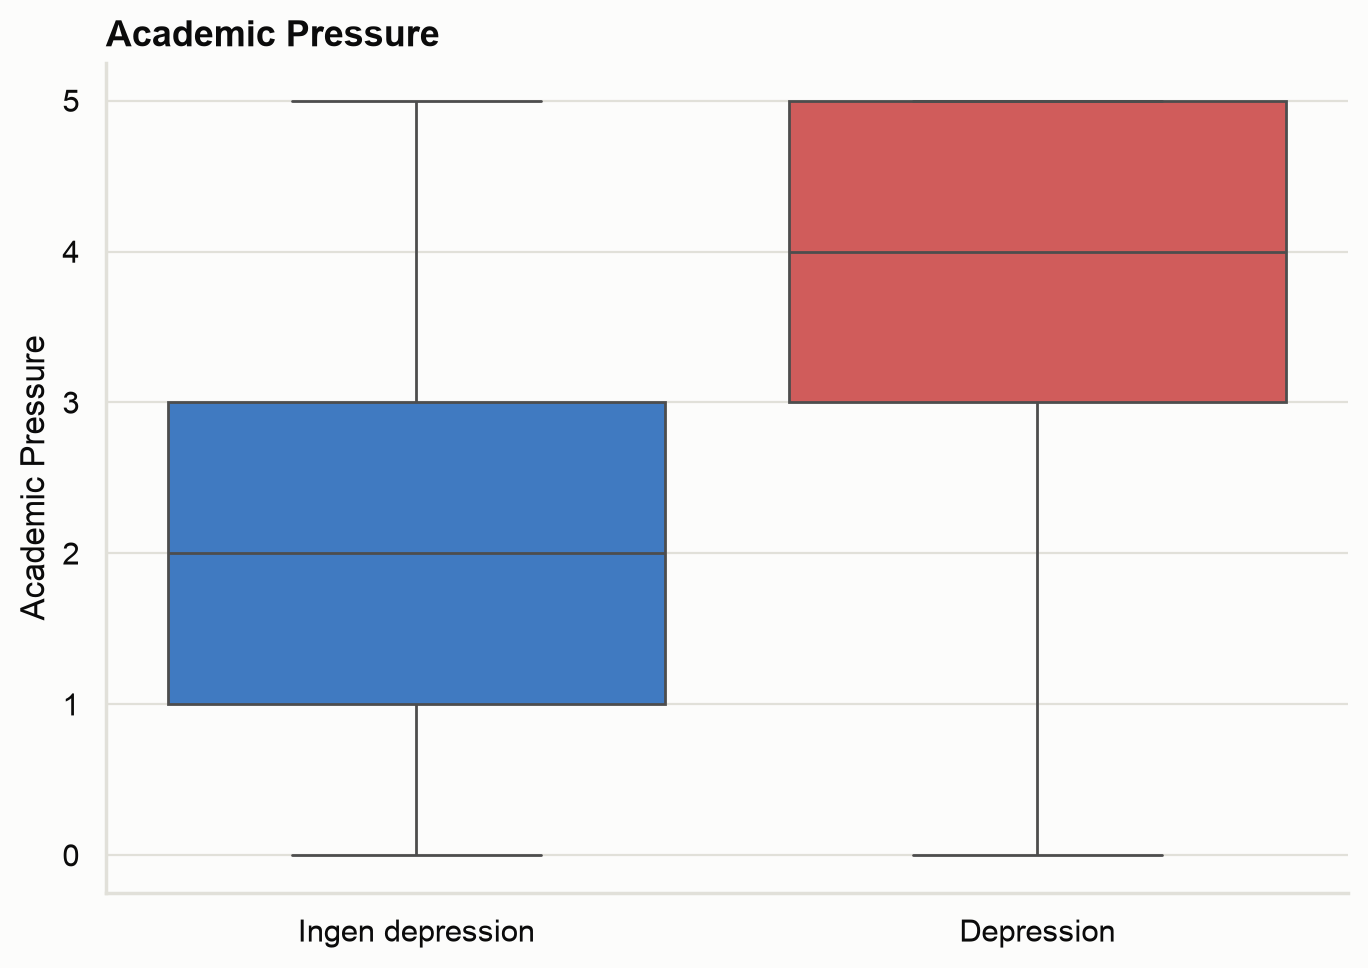

In [11]:
# Boxplot: Academic Pressure per Depression-grupp. Färgerna kommer från temacellens palett.
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Depression", y="Academic Pressure", hue="Depression", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ingen depression", "Depression"])
ax.set_xlabel("")
ax.set_title("Academic Pressure")
plt.tight_layout()
plt.show()

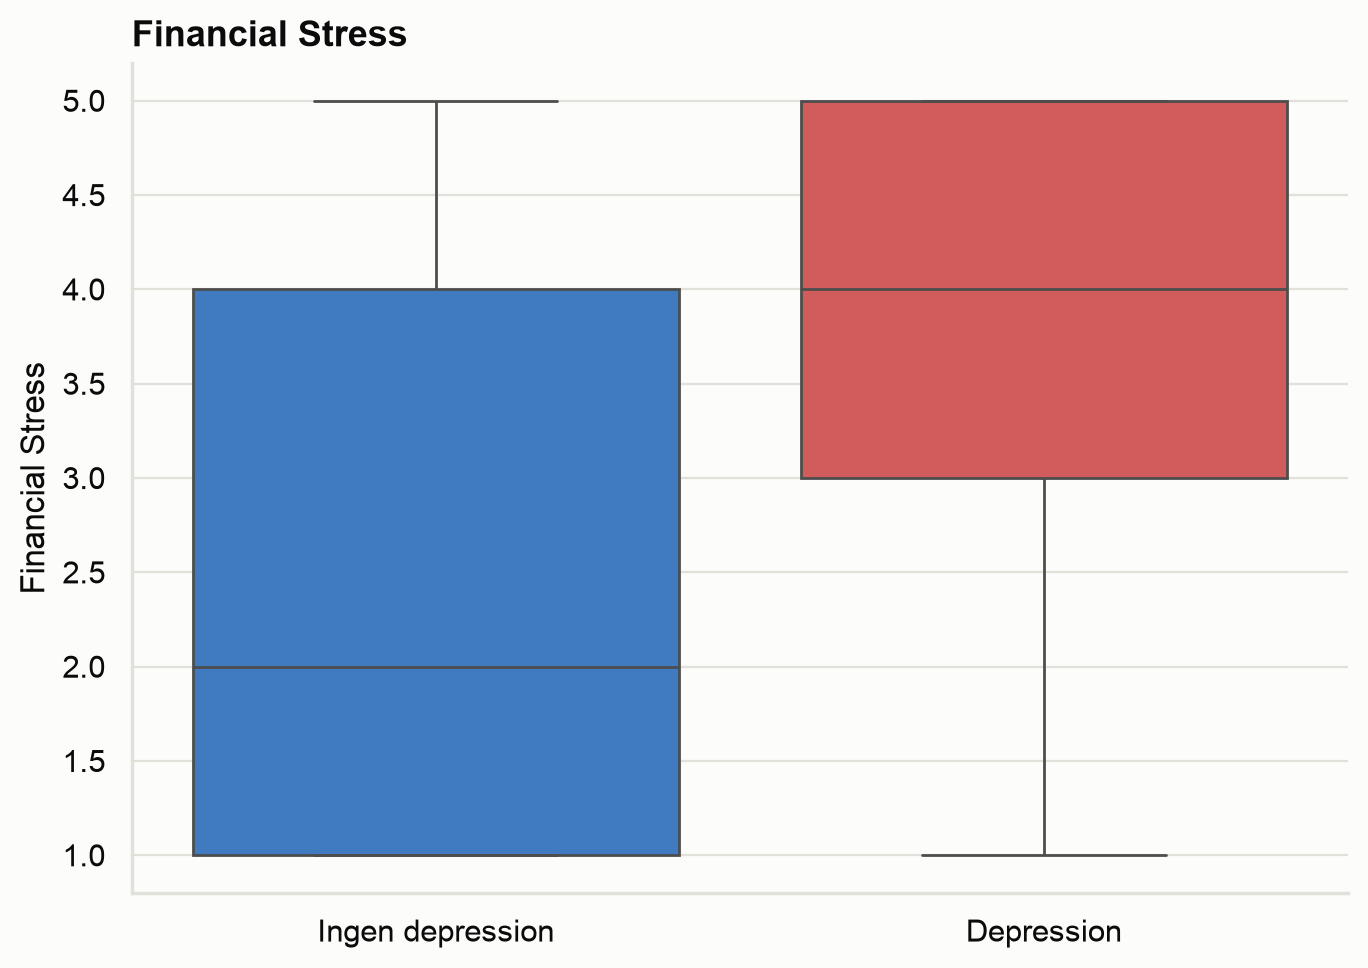

In [12]:
# Samma uppställning för Financial Stress.
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Depression", y="Financial Stress", hue="Depression", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ingen depression", "Depression"])
ax.set_xlabel("")
ax.set_title("Financial Stress")
plt.tight_layout()
plt.show()

## 7. Slutsatser

**Målvariabelns balans.** 58.6% med Depression / 41.4% utan – rimligt balanserat. Ingen
särskild balanseringsteknik (t.ex. SMOTE) bör behövas inför modellering.

**Starkast kopplade variabler (korrelationsheatmapen).** Suicidal thoughts (0.55), Academic
Pressure (0.47) och Financial Stress (0.36) toppar. **Suicidal thoughts exkluderas dock från
modelleringen i steg 4** – kopplingen till Depression bedöms vara för nära sammanflätad med
själva diagnosen (jämför DSM-5-kriterierna för egentlig depression, där återkommande
suicidtankar är ett av symptomkriterierna) för att räknas som en oberoende, meningsfull
prediktor. Att inkludera den hade snarare mätt hur väl ett symptom korrelerar med sin egen
diagnos än gett en genuint prediktiv modell.

**Svaga/oviktiga variabler.** CGPA (0.02) och Gender (0.00) är i praktiken irrelevanta för
Depression i det här datasetet - kandidater att nedprioritera vid modellering.

**Bekräftat visuellt (boxplottarna).** Academic Pressure visade en tydligare, skarpare
separation mellan grupperna än Financial Stress, trots att båda har måttlig-till-stark
korrelation - en påminnelse om att korrelationens styrka inte alltid syns lika tydligt i en
visuell jämförelse.

**Implikationer för nästa steg.**
- Livsstilsvariabler (Sleep Duration, Dietary Habits, Academic Pressure, Financial Stress,
  Work/Study Hours) är kandidater till klustringssteget (steg 3).
- Numeriska variabler behöver **skalas** (t.ex. StandardScaler) innan PCA/klustring, eftersom
  de har mycket olika värdeintervall (Age 18-59 vs Dietary Habits 1-3) och skulle annars
  dominera resultatet omotiverat.
- Suicidal thoughts exkluderas helt från den supervised modelleringen i steg 4, av skälet
  ovan.